In [68]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re

# IOB Fits


Reading from configuration file: conf/iob_6.ini

Reading from configuration file: conf/selection_0.ini

Target: log10A

RMSE train: 2.181e-01
		1 sigma: -0.10410828114848013 0.16251499680422674
		RMSE: 0.086351884613022
		RMAE: 0.04060179915536252
		1 sigma: -0.056209034908685146 0.05374481261527004
Median absolute DF/F 0.006400465289415513
RMSE DF/F 0.04778184506547065

RMSE val: 2.232e-01
		1 sigma: -0.10935973110138313 0.1546921277848364
		RMSE: 0.07744424922043337
		RMAE: 0.039997584192867454
		1 sigma: -0.049032403112846644 0.052422613338368444
Median absolute DF/F 0.006201570591020389
RMSE DF/F 0.043982663639795506

Reading from configuration file: conf/iob_6.ini

Reading from configuration file: conf/selection_0.ini

Target: log10A


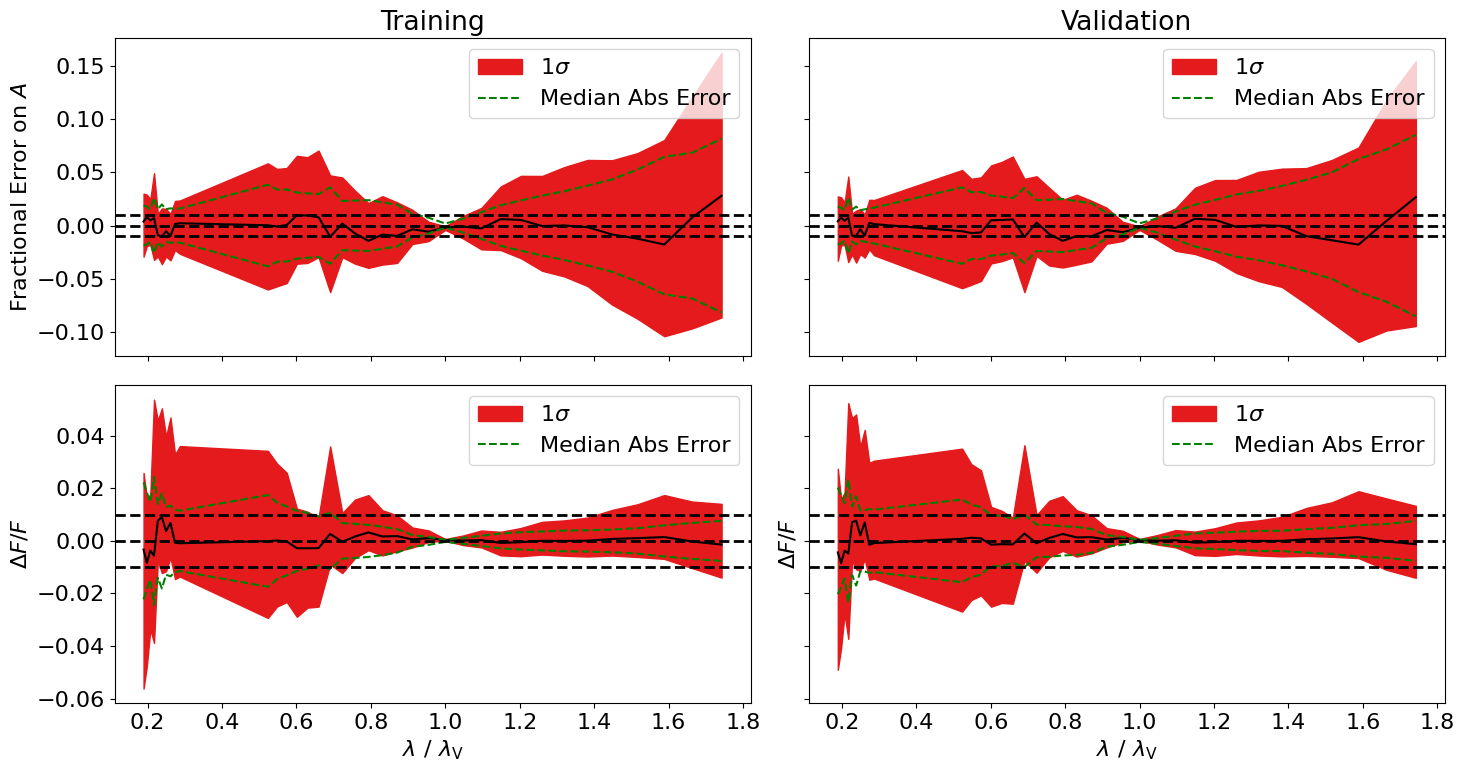

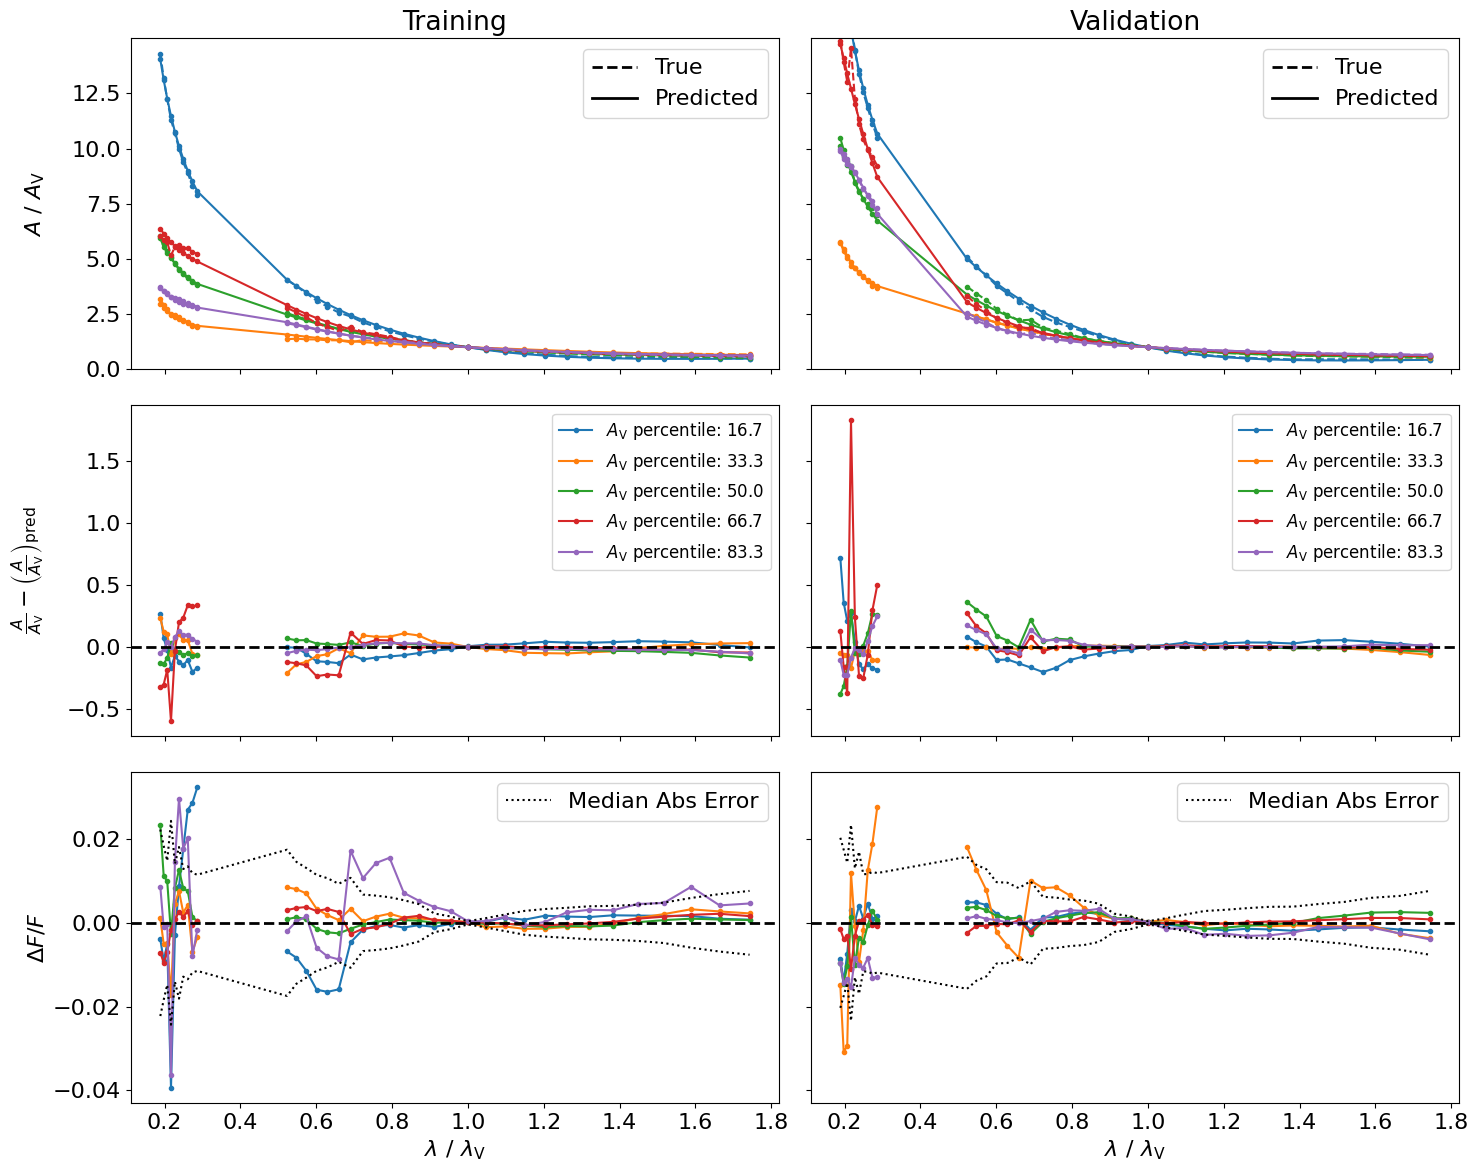

In [69]:
ini_file = 'conf/iob_0.ini'; ilen = None
ini_file = 'conf/iob_1.ini'; ilen = None
ini_file = 'conf/iob_2.ini'; ilen = None
ini_file = 'conf/iob_3.ini'; ilen = None
ini_file = 'conf/iob_4.ini'; ilen = None
# ini_file = 'conf/iob_5.ini'; ilen = None
ini_file = 'conf/iob_6.ini'; ilen = None
# ilen = 37

# processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=True);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=5, plot_av_diff=True, plot_dF_F=True, yscale='linear');
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_6.ini
1.1562242401210138e-06
0.6440796931067786


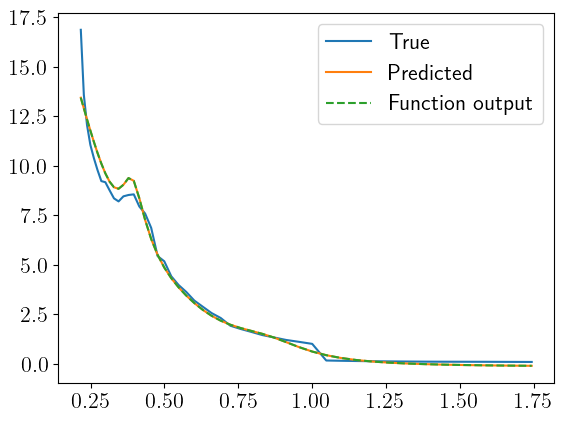

In [70]:
name = 'train'
ini_file = 'conf/iob_6.ini'; ilen = 32

all_data = pd.read_csv('../data/gal_los_iobcomp_attcurve_galprop.dat', sep='\t')
matches = pd.read_csv(f'../symbolic_regression/data/iob_data_10/iob_{name}_galaxy_ids_los.txt', sep='\t',)
matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
data_train = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
fit_data = pd.read_csv("../data/galaxy_optimization_results.csv")
fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
data_train = data_train.merge(fit_data, on=['galaxy_id', 'los'], how='inner')

# Get AV
attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ytrue = data[:,args.npar+1]
ypred = data[:,args.npar+2]
if args.fit_log:
    ypred = 10. ** ypred
    ytrue = 10. ** ytrue
fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(lam))
ytrue = ytrue.reshape(-1, len(lam))

for i in [4]:
    gal_id = matches['galaxy_id'].values[i]
    los = matches['los'].values[i]
    row = data_train[(data_train['galaxy_id'] == gal_id) & (data_train['los'] == los)]
    iob_cols = sorted([col for col in row.columns if re.match(r'IOB\d+', col)])
    IOB = row[iob_cols].values[0]
    B = sr_fun.compute_initial_B(IOB)
    new_pred = sr_fun.compute_Av(lam, *B)

    plt.plot(lam, ytrue[i], label='True')
    plt.plot(lam, ypred[i], label='Predicted')
    plt.plot(lam, new_pred, label='Function output', ls='--')
    plt.legend()

    print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
    print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values



# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


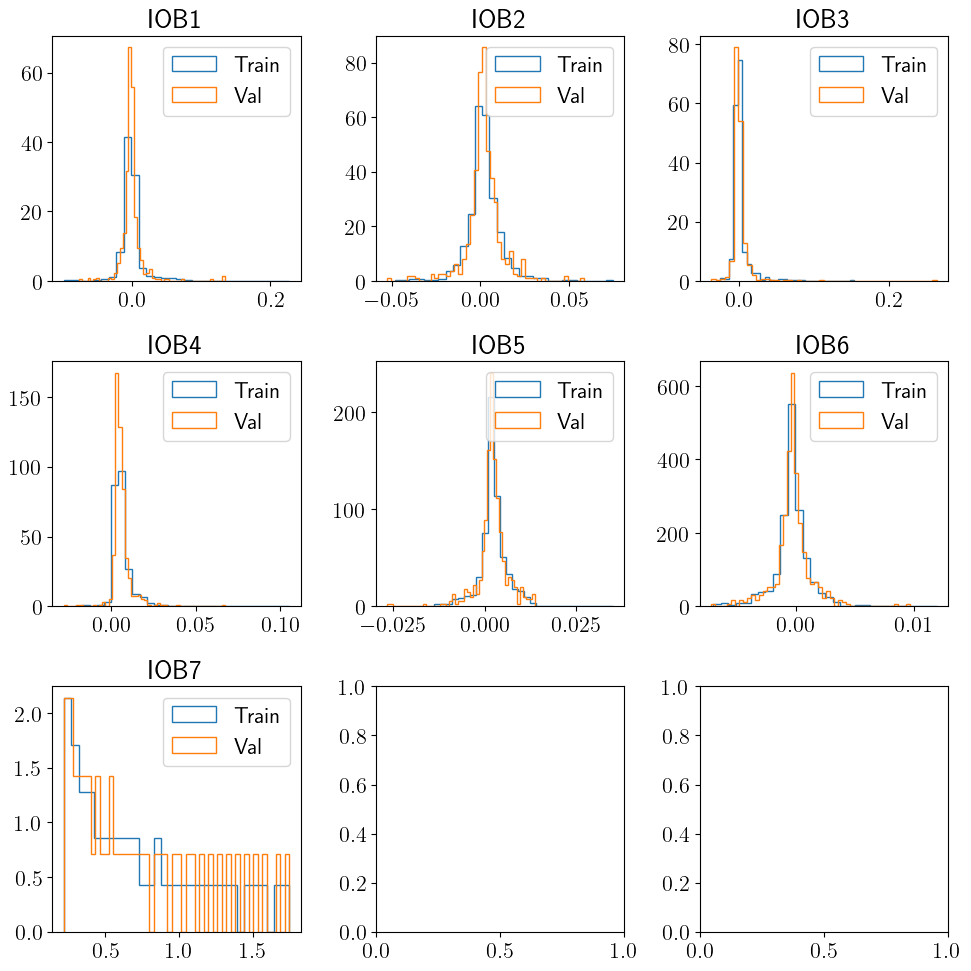

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()